In [1]:
import pandas as pd
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.metrics import roc_auc_score, roc_curve
from scipy import stats

pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

print('Libraries loaded successfully')

/Users/shivamverma/anaconda3/lib/python3.10/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Libraries loaded successfully


In [2]:
base = os.path.join(
    os.path.expanduser('~'), 'Desktop',
    'Credit-Risk-Analytics-Portfolio',
    '01_scorecard_development'
)

# Scored datasets from notebook 04
train_scored = pd.read_csv(os.path.join(base, 'outputs', 'train_scored.csv'))
oot_scored   = pd.read_csv(os.path.join(base, 'outputs', 'oot_scored.csv'))

# WOE datasets for CSI analysis
train_woe = pd.read_csv(os.path.join(base, 'data', 'train_woe.csv'))
oot_woe   = pd.read_csv(os.path.join(base, 'data', 'oot_woe.csv'))

print('Data loaded successfully')
print(f'Train scored : {train_scored.shape}')
print(f'OOT scored   : {oot_scored.shape}')
print(f'Train default rate : {train_scored["TARGET"].mean()*100:.2f}%')
print(f'OOT default rate   : {oot_scored["TARGET"].mean()*100:.2f}%')

Data loaded successfully
Train scored : (246008, 14)
OOT scored   : (61503, 14)
Train default rate : 8.07%
OOT default rate   : 8.07%


In [3]:
def full_discrimination_metrics(y_true, y_prob, label):
    """
    Calculate complete set of discrimination metrics.
    Returns dictionary with all metrics.
    """
    # AUROC and Gini
    auroc = roc_auc_score(y_true, y_prob)
    gini  = 2 * auroc - 1

    # KS statistic
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    ks = max(tpr - fpr)

    # Brier Score - measures calibration accuracy
    # Lower is better. Perfect model = 0. Random = 0.25
    brier = np.mean((y_prob - y_true) ** 2)

    # Log Loss
    eps = 1e-10
    log_loss = -np.mean(
        y_true * np.log(y_prob + eps) +
        (1 - y_true) * np.log(1 - y_prob + eps)
    )

    return {
        'Dataset'  : label,
        'AUROC'    : round(auroc, 4),
        'Gini'     : round(gini, 4),
        'Gini_%'   : round(gini * 100, 2),
        'KS'       : round(ks, 4),
        'KS_%'     : round(ks * 100, 2),
        'Brier'    : round(brier, 4),
        'Log_Loss' : round(log_loss, 4)
    }

train_metrics = full_discrimination_metrics(
    train_scored['TARGET'], train_scored['PRED_PROB'], 'TRAIN'
)
oot_metrics = full_discrimination_metrics(
    oot_scored['TARGET'], oot_scored['PRED_PROB'], 'OOT'
)

metrics_df = pd.DataFrame([train_metrics, oot_metrics])

print('SECTION 1: DISCRIMINATORY POWER')
print('='*65)
print(metrics_df.to_string(index=False))

# Stability check
gini_drop = train_metrics['Gini'] - oot_metrics['Gini']
ks_drop   = train_metrics['KS']   - oot_metrics['KS']

print(f'\nSTABILITY CHECK')
print(f'  Gini drop Train to OOT : {gini_drop*100:.2f}%  {"PASS" if gini_drop < 0.05 else "FAIL - investigate"}')
print(f'  KS drop Train to OOT   : {ks_drop*100:.2f}%  {"PASS" if ks_drop < 0.05 else "FAIL - investigate"}')

print(f'\nBENCHMARK CHECK (OOT)')
print(f'  Gini > 40% : {oot_metrics["Gini_%"]}%  {"PASS" if oot_metrics["Gini"] > 0.40 else "FAIL"}')
print(f'  KS > 30%   : {oot_metrics["KS_%"]}%  {"PASS" if oot_metrics["KS"] > 0.30 else "FAIL"}')

SECTION 1: DISCRIMINATORY POWER
Dataset  AUROC   Gini  Gini_%     KS    KS_%  Brier  Log_Loss
  TRAIN 0.7241 0.4481 44.8100 0.3308 33.0800 0.0698    0.2554
    OOT 0.7270 0.4540 45.4000 0.3366 33.6600 0.0695    0.2544

STABILITY CHECK
  Gini drop Train to OOT : -0.59%  PASS
  KS drop Train to OOT   : -0.58%  PASS

BENCHMARK CHECK (OOT)
  Gini > 40% : 45.4%  PASS
  KS > 30%   : 33.66%  PASS


In [4]:
def bootstrap_gini_ci(y_true, y_prob, n_bootstrap=1000, ci=0.95):
    """
    Calculate Gini confidence interval using bootstrap.
    n_bootstrap: number of resamples (1000 is standard)
    ci: confidence level (0.95 = 95% CI)
    """
    gini_scores = []
    n = len(y_true)

    for _ in range(n_bootstrap):
        # Resample with replacement
        idx        = np.random.choice(n, n, replace=True)
        y_sample   = np.array(y_true)[idx]
        prob_sample = np.array(y_prob)[idx]

        # Skip if only one class in sample
        if len(np.unique(y_sample)) < 2:
            continue

        auroc = roc_auc_score(y_sample, prob_sample)
        gini_scores.append(2 * auroc - 1)

    alpha    = (1 - ci) / 2
    lower_ci = np.percentile(gini_scores, alpha * 100)
    upper_ci = np.percentile(gini_scores, (1 - alpha) * 100)
    mean_g   = np.mean(gini_scores)

    return mean_g, lower_ci, upper_ci

print('Calculating bootstrap confidence intervals (1000 iterations)...')

np.random.seed(42)
train_mean, train_lower, train_upper = bootstrap_gini_ci(
    train_scored['TARGET'], train_scored['PRED_PROB']
)
oot_mean, oot_lower, oot_upper = bootstrap_gini_ci(
    oot_scored['TARGET'], oot_scored['PRED_PROB']
)

print('\nGini 95% Confidence Intervals')
print('='*55)
print(f'Train : {train_mean*100:.2f}%  [{train_lower*100:.2f}% - {train_upper*100:.2f}%]')
print(f'OOT   : {oot_mean*100:.2f}%  [{oot_lower*100:.2f}% - {oot_upper*100:.2f}%]')
print(f'\nOOT lower bound > 40%: {"PASS" if oot_lower > 0.40 else "FAIL - lower bound below threshold"}')

Calculating bootstrap confidence intervals (1000 iterations)...

Gini 95% Confidence Intervals
Train : 44.82%  [44.10% - 45.52%]
OOT   : 45.38%  [43.89% - 46.85%]

OOT lower bound > 40%: PASS


In [5]:
def calculate_psi_scores(train_scores, oot_scores, n_bins=10):
    """
    Calculate PSI on predicted probability scores.
    Bins are defined on TRAIN data, then applied to OOT.
    """
    # Create bins based on train score distribution
    _, bin_edges = pd.qcut(train_scores, q=n_bins, retbins=True, duplicates='drop')
    bin_edges[0]  = -np.inf
    bin_edges[-1] = np.inf

    # Count observations in each bin
    train_counts = pd.cut(train_scores, bins=bin_edges).value_counts(sort=False)
    oot_counts   = pd.cut(oot_scores,   bins=bin_edges).value_counts(sort=False)

    # Convert to proportions
    train_pct = train_counts / len(train_scores)
    oot_pct   = oot_counts   / len(oot_scores)

    # Replace zeros to avoid log(0)
    train_pct = train_pct.replace(0, 0.0001)
    oot_pct   = oot_pct.replace(0, 0.0001)

    # PSI formula
    psi_bins = (oot_pct - train_pct) * np.log(oot_pct / train_pct)
    psi_total = psi_bins.sum()

    psi_table = pd.DataFrame({
        'Bin'      : range(1, len(train_pct) + 1),
        'Train_%'  : (train_pct.values * 100).round(2),
        'OOT_%'    : (oot_pct.values * 100).round(2),
        'PSI_Bin'  : psi_bins.values.round(4)
    })

    return psi_total, psi_table

psi_total, psi_table = calculate_psi_scores(
    train_scored['PRED_PROB'],
    oot_scored['PRED_PROB']
)

if psi_total < 0.10:
    psi_status = 'STABLE - No significant shift'
elif psi_total < 0.25:
    psi_status = 'MONITOR - Minor shift detected'
else:
    psi_status = 'UNSTABLE - Major shift - investigate'

print('SECTION 2: POPULATION STABILITY INDEX (PSI)')
print('='*55)
print(f'PSI Total : {psi_total:.4f}')
print(f'Status    : {psi_status}')
print()
print('PSI by Score Bin:')
print(psi_table.to_string(index=False))

SECTION 2: POPULATION STABILITY INDEX (PSI)
PSI Total : 0.0003
Status    : STABLE - No significant shift

PSI by Score Bin:
 Bin  Train_%   OOT_%  PSI_Bin
   1  10.0000 10.0400   0.0000
   2  10.0000  9.9300   0.0000
   3  10.0000 10.3100   0.0001
   4  10.0000  9.8900   0.0000
   5  10.0000  9.9100   0.0000
   6  10.0000  9.8400   0.0000
   7  10.0000 10.3700   0.0001
   8  10.0000  9.9600   0.0000
   9  10.0000  9.8600   0.0000
  10  10.0000  9.9000   0.0000


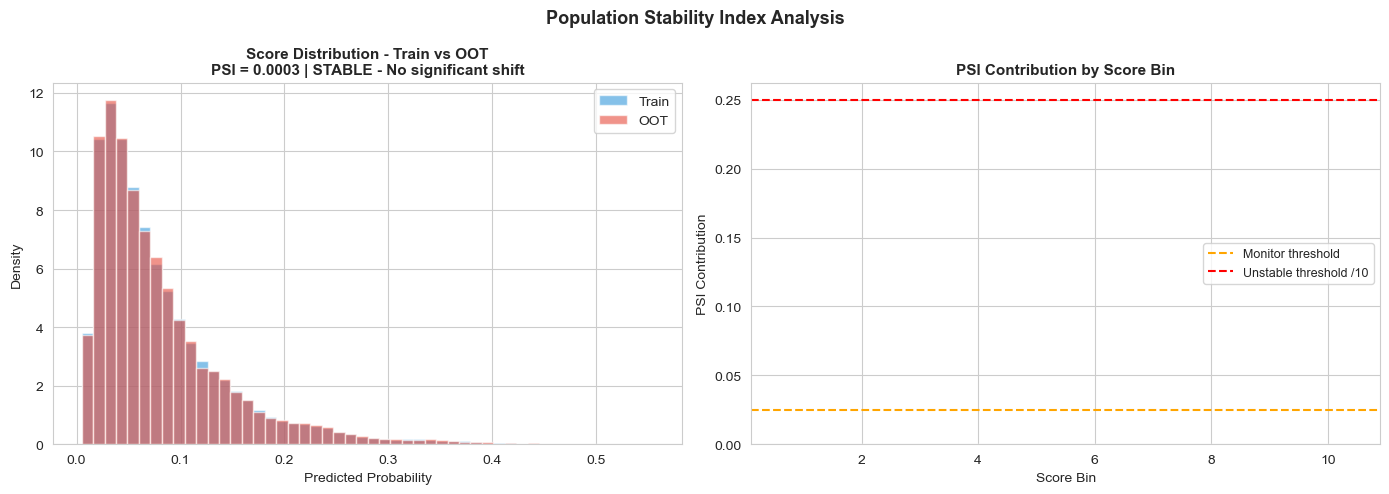

PSI chart saved


In [6]:
# PSI Score Distribution Chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Score distribution comparison
axes[0].hist(train_scored['PRED_PROB'], bins=50, alpha=0.6,
             color='#3498db', label='Train', density=True)
axes[0].hist(oot_scored['PRED_PROB'], bins=50, alpha=0.6,
             color='#e74c3c', label='OOT', density=True)
axes[0].set_xlabel('Predicted Probability')
axes[0].set_ylabel('Density')
axes[0].set_title(f'Score Distribution - Train vs OOT\nPSI = {psi_total:.4f} | {psi_status}',
                  fontsize=11, fontweight='bold')
axes[0].legend()

# PSI by bin
bar_colors = ['#2ecc71' if p < 0.01 else '#f39c12' if p < 0.025 else '#e74c3c'
              for p in psi_table['PSI_Bin']]
axes[1].bar(psi_table['Bin'], psi_table['PSI_Bin'], color=bar_colors, edgecolor='white')
axes[1].axhline(y=0.025, color='orange', linestyle='--', linewidth=1.5, label='Monitor threshold')
axes[1].axhline(y=0.025*10, color='red', linestyle='--', linewidth=1.5, label='Unstable threshold /10')
axes[1].set_xlabel('Score Bin')
axes[1].set_ylabel('PSI Contribution')
axes[1].set_title('PSI Contribution by Score Bin', fontsize=11, fontweight='bold')
axes[1].legend(fontsize=9)

plt.suptitle('Population Stability Index Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(base, 'outputs', '17_psi_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()
print('PSI chart saved')

In [7]:
def calculate_csi(train_series, oot_series, n_bins=10):
    """
    Calculate CSI for a single variable.
    Same logic as PSI but applied to individual features.
    """
    try:
        _, bin_edges = pd.qcut(train_series, q=n_bins, retbins=True, duplicates='drop')
        bin_edges[0]  = -np.inf
        bin_edges[-1] = np.inf

        train_counts = pd.cut(train_series, bins=bin_edges).value_counts(sort=False)
        oot_counts   = pd.cut(oot_series,   bins=bin_edges).value_counts(sort=False)

        train_pct = (train_counts / len(train_series)).replace(0, 0.0001)
        oot_pct   = (oot_counts   / len(oot_series)).replace(0, 0.0001)

        csi = ((oot_pct - train_pct) * np.log(oot_pct / train_pct)).sum()
        return abs(csi)
    except Exception:
        return np.nan

# Calculate CSI for all WOE variables
feature_cols = [c for c in train_woe.columns if c != 'TARGET']

csi_results = []
for col in feature_cols:
    csi_val = calculate_csi(train_woe[col], oot_woe[col])
    if not np.isnan(csi_val):
        if csi_val < 0.10:
            status = 'Stable'
        elif csi_val < 0.25:
            status = 'Monitor'
        else:
            status = 'Unstable'
        csi_results.append({'Variable': col, 'CSI': round(csi_val, 4), 'Status': status})

csi_df = pd.DataFrame(csi_results).sort_values('CSI', ascending=False)

print('SECTION 3: CHARACTERISTIC STABILITY INDEX (CSI)')
print('='*55)
print(csi_df.to_string(index=False))
print(f'\nStable   : {len(csi_df[csi_df["Status"]=="Stable"])}')
print(f'Monitor  : {len(csi_df[csi_df["Status"]=="Monitor"])}')
print(f'Unstable : {len(csi_df[csi_df["Status"]=="Unstable"])}')

csi_df.to_csv(os.path.join(base, 'outputs', 'csi_results.csv'), index=False)
print('\nCSI results saved')

SECTION 3: CHARACTERISTIC STABILITY INDEX (CSI)
                  Variable    CSI Status
DAYS_LAST_PHONE_CHANGE_woe 0.0003 Stable
          EXT_SOURCE_3_woe 0.0002 Stable
     DAYS_REGISTRATION_woe 0.0001 Stable
             AGE_YEARS_woe 0.0001 Stable
       AMT_GOODS_PRICE_woe 0.0001 Stable
  EMPLOYMENT_AGE_RATIO_woe 0.0000 Stable
       DAYS_ID_PUBLISH_woe 0.0000 Stable
          EXT_SOURCE_2_woe 0.0000 Stable
    CREDIT_GOODS_RATIO_woe 0.0000 Stable
            AMT_CREDIT_woe 0.0000 Stable
      AMT_INCOME_TOTAL_woe 0.0000 Stable

Stable   : 11
Monitor  : 0
Unstable : 0

CSI results saved


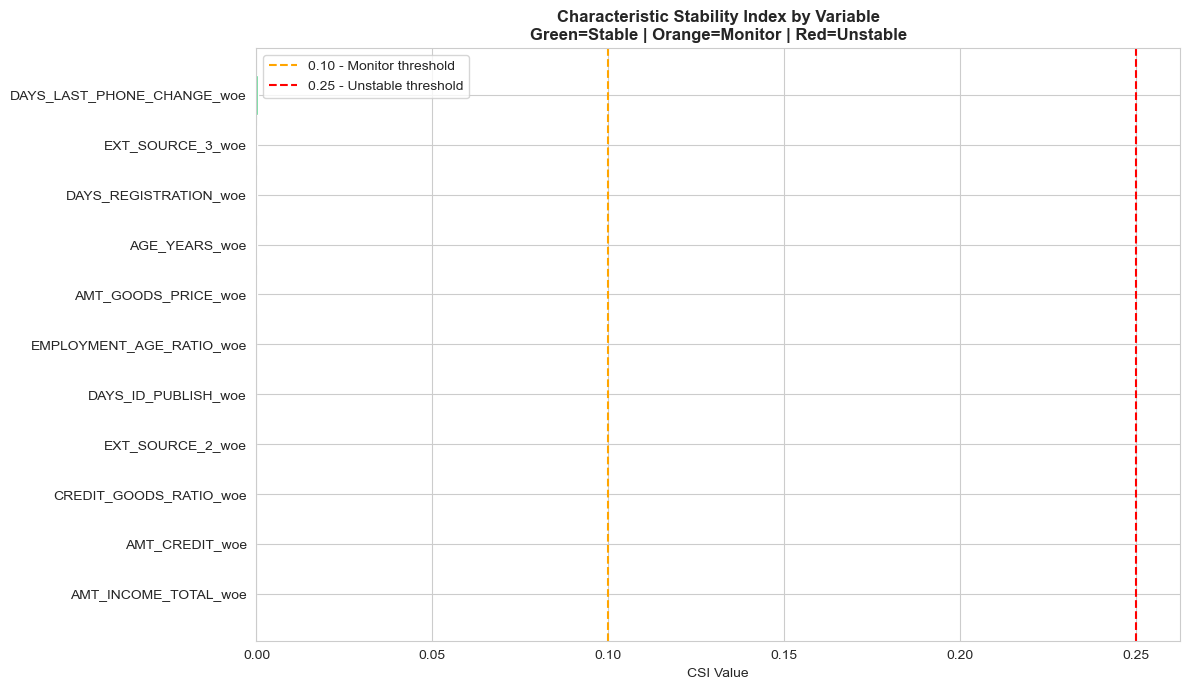

CSI chart saved


In [8]:
# CSI bar chart
fig, ax = plt.subplots(figsize=(12, 7))

colors_csi = ['#2ecc71' if s == 'Stable' else '#f39c12' if s == 'Monitor' else '#e74c3c'
              for s in csi_df['Status']]

ax.barh(csi_df['Variable'], csi_df['CSI'], color=colors_csi, edgecolor='white')
ax.axvline(x=0.10, color='orange', linestyle='--', linewidth=1.5, label='0.10 - Monitor threshold')
ax.axvline(x=0.25, color='red',    linestyle='--', linewidth=1.5, label='0.25 - Unstable threshold')
ax.set_xlabel('CSI Value')
ax.set_title('Characteristic Stability Index by Variable\nGreen=Stable | Orange=Monitor | Red=Unstable',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.invert_yaxis()

plt.tight_layout()
plt.savefig(os.path.join(base, 'outputs', '18_csi_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()
print('CSI chart saved')

In [9]:
def hosmer_lemeshow_test(y_true, y_prob, n_groups=10):
    """
    Hosmer-Lemeshow goodness of fit test.
    Groups predictions into n_groups deciles.
    Compares observed vs expected defaults in each group.
    """
    df = pd.DataFrame({'prob': y_prob, 'actual': y_true})
    df['group'] = pd.qcut(df['prob'], q=n_groups, duplicates='drop', labels=False)

    grouped = df.groupby('group').agg(
        n         =('actual', 'count'),
        observed  =('actual', 'sum'),
        expected  =('prob',   'sum')
    ).reset_index()

    grouped['not_observed'] = grouped['n'] - grouped['observed']
    grouped['not_expected'] = grouped['n'] - grouped['expected']

    # HL chi-square statistic
    hl_stat = (
        ((grouped['observed'] - grouped['expected']) ** 2 /
         (grouped['expected'] * (1 - grouped['expected'] / grouped['n']) + 1e-10))
    ).sum()

    df_stat  = n_groups - 2
    p_value  = 1 - stats.chi2.cdf(hl_stat, df_stat)

    return hl_stat, p_value, grouped

# Run on OOT
hl_stat, p_value, hl_table = hosmer_lemeshow_test(
    oot_scored['TARGET'], oot_scored['PRED_PROB']
)

print('SECTION 4: CALIBRATION - HOSMER-LEMESHOW TEST (OOT)')
print('='*60)
print(f'HL Statistic : {hl_stat:.4f}')
print(f'p-value      : {p_value:.4f}')
print(f'Result       : {"PASS - Well calibrated (p > 0.05)" if p_value > 0.05 else "FAIL - Poor calibration (p <= 0.05)"}')
print()
print('Observed vs Expected Defaults by Decile:')
print(hl_table[['group','n','observed','expected']].round(2).to_string(index=False))

SECTION 4: CALIBRATION - HOSMER-LEMESHOW TEST (OOT)
HL Statistic : 6.0834
p-value      : 0.6379
Result       : PASS - Well calibrated (p > 0.05)

Observed vs Expected Defaults by Decile:
 group    n  observed  expected
     0 6152       103  101.6500
     1 6149       161  162.4200
     2 6150       215  214.3600
     3 6150       252  270.2800
     4 6151       347  335.1800
     5 6152       384  413.6100
     6 6148       515  508.4800
     7 6150       643  638.0800
     8 6151       851  855.0300
     9 6150      1494 1448.2700


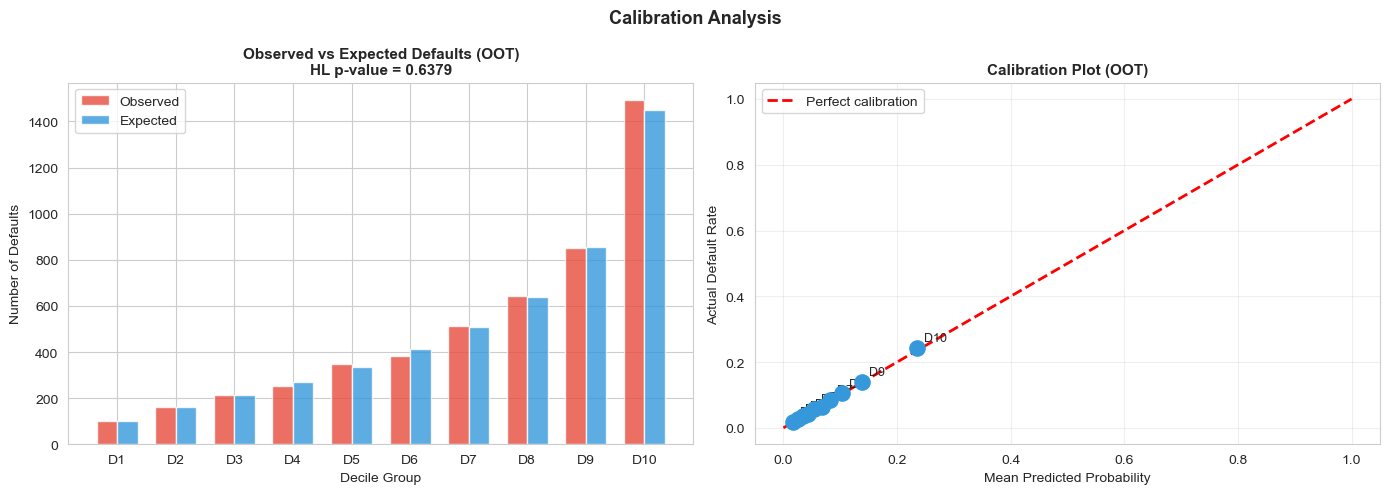

Calibration charts saved


In [10]:
# Calibration chart - observed vs expected
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = np.arange(len(hl_table))
width = 0.35

axes[0].bar(x - width/2, hl_table['observed'], width,
            label='Observed', color='#e74c3c', alpha=0.8)
axes[0].bar(x + width/2, hl_table['expected'], width,
            label='Expected', color='#3498db', alpha=0.8)
axes[0].set_xlabel('Decile Group')
axes[0].set_ylabel('Number of Defaults')
axes[0].set_title(f'Observed vs Expected Defaults (OOT)\nHL p-value = {p_value:.4f}',
                  fontsize=11, fontweight='bold')
axes[0].legend()
axes[0].set_xticks(x)
axes[0].set_xticklabels([f'D{i+1}' for i in range(len(hl_table))])

# Calibration scatter - predicted rate vs actual rate
calib_df = pd.DataFrame({'prob': oot_scored['PRED_PROB'], 'actual': oot_scored['TARGET']})
calib_df['decile'] = pd.qcut(calib_df['prob'], q=10, labels=False, duplicates='drop')
calib_summary = calib_df.groupby('decile').agg(
    mean_pred  =('prob',   'mean'),
    actual_rate=('actual', 'mean')
).reset_index()

axes[1].scatter(calib_summary['mean_pred'], calib_summary['actual_rate'],
                s=120, color='#3498db', zorder=5)
axes[1].plot([0,1],[0,1],'r--', linewidth=2, label='Perfect calibration')
for _, row in calib_summary.iterrows():
    axes[1].annotate(f'D{int(row["decile"])+1}',
                     (row['mean_pred'], row['actual_rate']),
                     textcoords='offset points', xytext=(5,5), fontsize=9)
axes[1].set_xlabel('Mean Predicted Probability')
axes[1].set_ylabel('Actual Default Rate')
axes[1].set_title('Calibration Plot (OOT)', fontsize=11, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Calibration Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(base, 'outputs', '19_calibration_test.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Calibration charts saved')

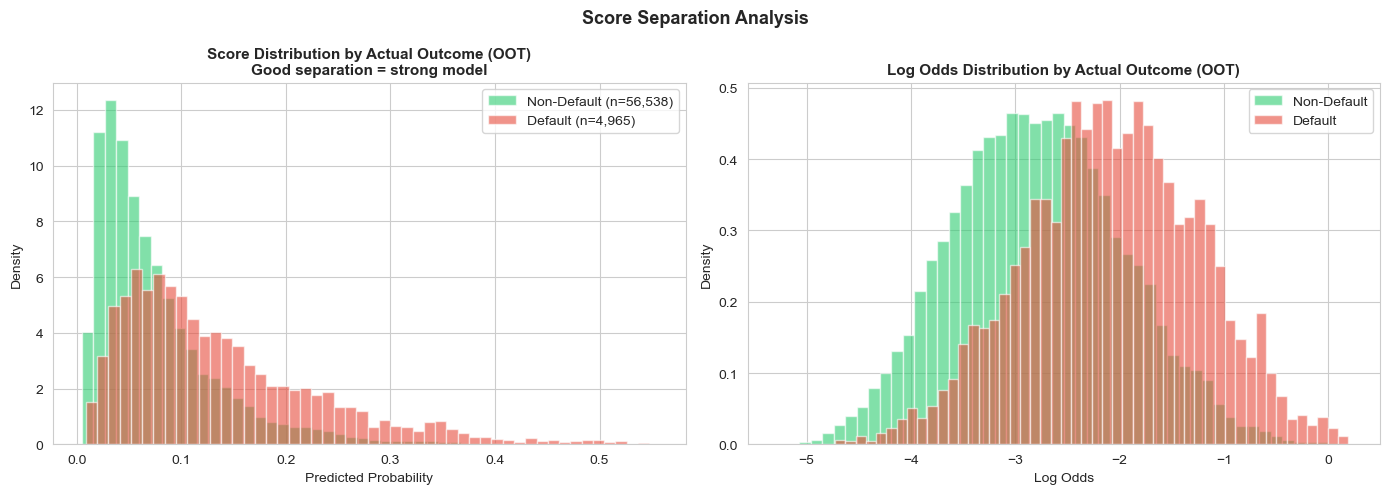

Score separation chart saved


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Score distribution by actual outcome (OOT)
oot_good = oot_scored[oot_scored['TARGET'] == 0]['PRED_PROB']
oot_bad  = oot_scored[oot_scored['TARGET'] == 1]['PRED_PROB']

axes[0].hist(oot_good, bins=50, alpha=0.6, color='#2ecc71',
             label=f'Non-Default (n={len(oot_good):,})', density=True)
axes[0].hist(oot_bad,  bins=50, alpha=0.6, color='#e74c3c',
             label=f'Default (n={len(oot_bad):,})', density=True)
axes[0].set_xlabel('Predicted Probability')
axes[0].set_ylabel('Density')
axes[0].set_title('Score Distribution by Actual Outcome (OOT)\nGood separation = strong model',
                  fontsize=11, fontweight='bold')
axes[0].legend()

# Log odds distribution
axes[1].hist(oot_scored[oot_scored['TARGET']==0]['LOG_ODDS'], bins=50,
             alpha=0.6, color='#2ecc71', label='Non-Default', density=True)
axes[1].hist(oot_scored[oot_scored['TARGET']==1]['LOG_ODDS'], bins=50,
             alpha=0.6, color='#e74c3c', label='Default', density=True)
axes[1].set_xlabel('Log Odds')
axes[1].set_ylabel('Density')
axes[1].set_title('Log Odds Distribution by Actual Outcome (OOT)',
                  fontsize=11, fontweight='bold')
axes[1].legend()

plt.suptitle('Score Separation Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(base, 'outputs', '20_score_separation.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Score separation chart saved')

In [12]:
# Build fine-grained decile table for rank ordering test
rank_df = pd.DataFrame({
    'prob'  : oot_scored['PRED_PROB'],
    'actual': oot_scored['TARGET']
})
rank_df = rank_df.sort_values('prob', ascending=False).reset_index(drop=True)
rank_df['decile'] = pd.qcut(rank_df.index, q=20,
                             labels=[f'V{i:02d}' for i in range(1, 21)])

rank_summary = rank_df.groupby('decile', observed=True).agg(
    Count       =('actual', 'count'),
    Defaults    =('actual', 'sum'),
    Default_Rate=('actual', 'mean'),
    Mean_Prob   =('prob',   'mean')
).reset_index()

rank_summary['Default_Rate_%'] = (rank_summary['Default_Rate'] * 100).round(2)

# Check monotonicity
rates = rank_summary['Default_Rate'].values
violations = sum(1 for i in range(len(rates)-1) if rates[i] < rates[i+1])

print('SECTION 5: RANK ORDERING TEST (OOT - 20 Ventiles)')
print('='*60)
print(rank_summary[['decile','Count','Defaults','Default_Rate_%','Mean_Prob']].to_string(index=False))
print(f'\nRank ordering violations : {violations} out of {len(rates)-1} transitions')
print(f'Result: {"PASS - Good rank ordering" if violations <= 2 else "REVIEW - Multiple violations"}')

SECTION 5: RANK ORDERING TEST (OOT - 20 Ventiles)
decile  Count  Defaults  Default_Rate_%  Mean_Prob
   V01   3076       906         29.4500     0.2833
   V02   3075       588         19.1200     0.1876
   V03   3075       450         14.6300     0.1501
   V04   3075       401         13.0400     0.1279
   V05   3075       340         11.0600     0.1102
   V06   3075       303          9.8500     0.0973
   V07   3075       277          9.0100     0.0870
   V08   3075       238          7.7400     0.0784
   V09   3075       206          6.7000     0.0707
   V10   3076       178          5.7900     0.0638
   V11   3075       198          6.4400     0.0574
   V12   3075       149          4.8500     0.0516
   V13   3075       135          4.3900     0.0464
   V14   3075       117          3.8000     0.0415
   V15   3075        93          3.0200     0.0370
   V16   3075       122          3.9700     0.0327
   V17   3075        93          3.0200     0.0286
   V18   3075        68         

In [13]:
# Create comprehensive validation summary
summary_data = [
    ['1. Discriminatory Power', 'Gini (OOT)',
     f'{oot_metrics["Gini_%"]}%',
     '>40%',
     'PASS' if oot_metrics['Gini'] > 0.40 else 'FAIL'],

    ['1. Discriminatory Power', 'KS (OOT)',
     f'{oot_metrics["KS_%"]}%',
     '>30%',
     'PASS' if oot_metrics['KS'] > 0.30 else 'FAIL'],

    ['1. Discriminatory Power', 'Gini Drop Train-OOT',
     f'{(train_metrics["Gini"]-oot_metrics["Gini"])*100:.2f}%',
     '<5%',
     'PASS' if (train_metrics['Gini']-oot_metrics['Gini']) < 0.05 else 'FAIL'],

    ['1. Discriminatory Power', 'Gini CI Lower Bound (OOT)',
     f'{oot_lower*100:.2f}%',
     '>40%',
     'PASS' if oot_lower > 0.40 else 'FAIL'],

    ['2. Population Stability', 'PSI (Score)',
     f'{psi_total:.4f}',
     '<0.10',
     'PASS' if psi_total < 0.10 else 'MONITOR' if psi_total < 0.25 else 'FAIL'],

    ['3. Characteristic Stability', 'Variables Stable (CSI<0.10)',
     f'{len(csi_df[csi_df["Status"]=="Stable"])} of {len(csi_df)}',
     'All stable',
     'PASS' if len(csi_df[csi_df['Status']!='Stable']) == 0 else 'MONITOR'],

    ['4. Calibration', 'Hosmer-Lemeshow p-value',
     f'{p_value:.4f}',
     '>0.05',
     'PASS' if p_value > 0.05 else 'FAIL'],

    ['5. Rank Ordering', 'Violations (20 ventiles)',
     f'{violations}',
     '<=2',
     'PASS' if violations <= 2 else 'FAIL']
]

summary_df = pd.DataFrame(summary_data,
    columns=['Section', 'Test', 'Result', 'Benchmark', 'Status'])

passes = len(summary_df[summary_df['Status'] == 'PASS'])
total  = len(summary_df)

print('='*75)
print('  MODEL VALIDATION SUMMARY REPORT')
print('='*75)
print(summary_df.to_string(index=False))
print('='*75)
print(f'  Overall: {passes}/{total} tests passed')
print(f'  Verdict: {"MODEL APPROVED FOR USE" if passes >= total*0.75 else "MODEL REQUIRES REMEDIATION"}')
print('='*75)

summary_df.to_csv(os.path.join(base, 'outputs', 'validation_summary.csv'), index=False)
print('\nValidation summary saved')

  MODEL VALIDATION SUMMARY REPORT
                    Section                        Test   Result  Benchmark Status
    1. Discriminatory Power                  Gini (OOT)    45.4%       >40%   PASS
    1. Discriminatory Power                    KS (OOT)   33.66%       >30%   PASS
    1. Discriminatory Power         Gini Drop Train-OOT   -0.59%        <5%   PASS
    1. Discriminatory Power   Gini CI Lower Bound (OOT)   43.89%       >40%   PASS
    2. Population Stability                 PSI (Score)   0.0003      <0.10   PASS
3. Characteristic Stability Variables Stable (CSI<0.10) 11 of 11 All stable   PASS
             4. Calibration     Hosmer-Lemeshow p-value   0.6379      >0.05   PASS
           5. Rank Ordering    Violations (20 ventiles)        2        <=2   PASS
  Overall: 8/8 tests passed
  Verdict: MODEL APPROVED FOR USE

Validation summary saved
